# IAPR 2026 — Final Project Report
## UNO Vision Challenge: Recovering Game State from Tabletop Snapshots

**Group:** `<group_id>` — `<kaggle_group_name>`

**Members:**
- `<Name 1>` — SCIPER `<xxxxxx>`
- `<Name 2>` — SCIPER `<xxxxxx>`
- `Dorian Besson` — SCIPER `346220`

---

> **How to read this report.** The notebook is organised as an executable
> walkthrough of our solution. Every section pairs a short written justification
> with the code that produced the figures. Re-running the notebook top-to-bottom
> regenerates every plot from the model checkpoints in `models/`. The
> exact Kaggle submission CSV is produced by running `python main.py` from the
> repository root.

## 1. Problem statement and approach

> *Write here:* one paragraph restating the task in our own words (per-image
> recovery of center card, active player, four hands), the dataset constraints
> (no external data, no pretrained weights, <=12M params per model, fixed
> player geometry), and a one-sentence preview of our pipeline.

### 1.1 Pipeline overview

Our solution is a five-stage pipeline:

1. **Segmentation.** A small U-Net produces a per-pixel card-foreground
   probability map.
2. **Instance extraction.** Connected components are split into per-card
   instance masks (with controlled mask dilation) and bounding boxes.
3. **Classification.** A masked 4-channel ResNet-18 (RGB + mask channel)
   classifies each crop into one of 54 UNO card types.
4. **Active-player token detection.** A deterministic OpenCV detector finds
   the dark rectangular token on plain backgrounds or the yellow round token
   on textured backgrounds, then maps its center to the fixed player sectors.
5. **Game-state assembly.** Boxes are assigned to a region (center, p1..p4)
   by geometry and written with the detected active player.

> *Write here:* justify the high-level decomposition. Why two models instead
> of an end-to-end detector? What is the trade-off?

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import cv2
import pandas as pd
from tqdm.auto import tqdm

from src.inference import (
    InferenceConfig,
    load_engine,
    predict_from_path,
    write_submission,
)

from src.data_augmentation import (
    CreateAugmentedDataConfig,
    initialize_create_augmented_data_pipeline,
    run_full_augmentation_pipeline,
    run_scene_preview,
    plot_scene_preview,
    summarize_augmented_data,
    print_augmentation_summary,
    plot_augmentation_overview,
)
from src.segmenter_training import (
    SegmenterPipelineConfig,
    run_full_segmenter_training,
    release_segmenter_training_resources,
    plot_training_curves,
    evaluate_segmenter_checkpoint,
    print_segmenter_summary,
    plot_segmenter_audit,
)
from src.classifier_training import (
    TrainPipelineConfig,
    run_full_classifier_training,
    plot_stage_preview,
    plot_classifier_training_curves,
    summarize_classifier_training,
    print_classifier_summary,
)
from src.report_viz import (
    BenchmarkConfig,
    run_labeled_benchmark,
    plot_pipeline_stages,
    plot_region_layout,
    plot_active_player_detection,
    summarize_active_player_detection,
    print_active_player_summary,
    plot_active_player_summary,
    summarize_prediction_set,
    print_prediction_set_summary,
    plot_prediction_set_diagnostics,
)

MODELS_DIR = REPO_ROOT / "models"
CHALLENGE_DIR = REPO_ROOT / "data" / "iapr-26-uno-vision-challenge"
TRAIN_DIR = CHALLENGE_DIR / "train_images"
TEST_DIR = CHALLENGE_DIR / "test_images"
TRAIN_CSV = CHALLENGE_DIR / "train.csv"

TRAINING_DATA_DIR = REPO_ROOT / "training_data"
OBJECT_LABELS_DIR = TRAINING_DATA_DIR / "object_labels"
AUGMENTED_DATA_DIR = TRAINING_DATA_DIR / "augmented_data"

GENERATED_SCENE_LABELS = OBJECT_LABELS_DIR / "augmented_scenes.json"
GENERATED_SCENE_IMAGES = AUGMENTED_DATA_DIR / "scene_images"
GENERATED_SCENE_MASKS = AUGMENTED_DATA_DIR / "scene_masks"
GENERATED_AUGMENTED_CARDS = OBJECT_LABELS_DIR / "augmented_cards.csv"

## 2. Compliance checks (R1–R6)

> *Write here:* state explicitly that our pipeline uses no external datasets
> and no pretrained weights, that the test set is only used for inference, and
> that both models fit under the 12M-parameter cap. Loading the engine below
> prints the trainable parameter count for each model and asserts the cap.

In [2]:
engine = load_engine(MODELS_DIR, config=InferenceConfig(), verbose=True)
print(f"\nClassifier classes: {len(engine.class_names)}")

[compliance] SceneUNetSmall (segmenter): 1,928,417 trainable params
[compliance] CardClassifier[resnet18_small]: 9,853,134 trainable params
[engine] device=cuda | classes=54 | card_img_size=160 | seg_threshold=0.5

Classifier classes: 54


## 3. Training Data Generation

The training set used by the two learned models is generated only from challenge assets: flat RGBA reference card crops, composited card augmentations, and synthetic full scenes with segmentation masks. The cell below contains the full regeneration call, but keeps the long write-heavy job behind an explicit flag so the report can be opened safely.

Project root: C:\Users\doria\Documents\EPFL\IA\iapr2026do
Reference assets: 54 crops from C:\Users\doria\Documents\EPFL\IA\iapr2026do\training_data\reference_data\card_crops
Augmented-card output: C:\Users\doria\Documents\EPFL\IA\iapr2026do\training_data\augmented_data\card_images (*.jpg)
Scene output: C:\Users\doria\Documents\EPFL\IA\iapr2026do\training_data\augmented_data\scene_images (*.jpg)
Preview scene: active=p2 cards=21


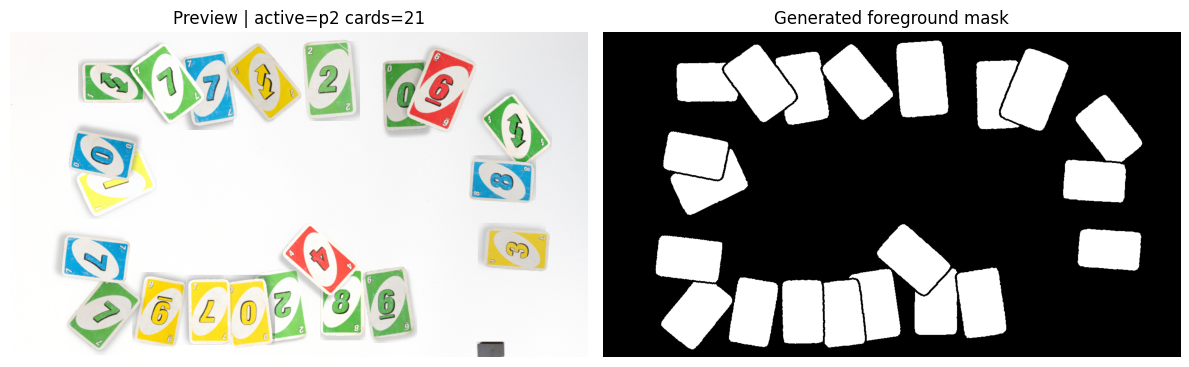

Set RUN_FULL_AUGMENTATION=True to rewrite augmented cards, scenes, masks, and augmented_scenes.json.
Generated data: 54 reference crops, 54,000 augmented crops, 12,288 scenes/12,288 masks.
Coverage: 54 reference classes, 54 augmented classes, cards/scene mean=13.01 range=1-25, active={'p1': 2993, 'p3': 3084, 'p4': 3062, 'p2': 3149}.


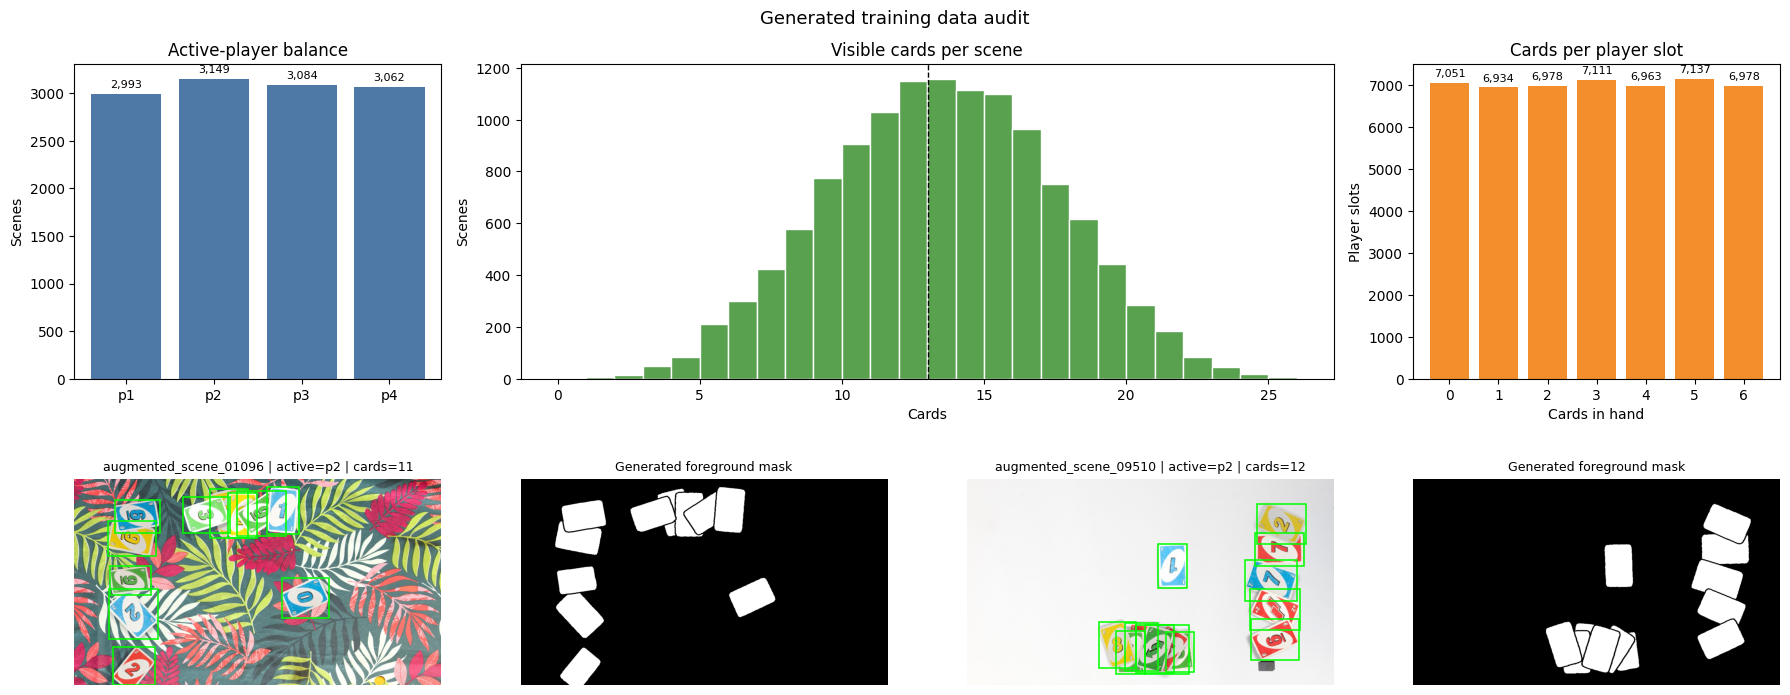

In [ ]:
RUN_FULL_AUGMENTATION = True

augmentation_config = CreateAugmentedDataConfig(clear_output_dirs=RUN_FULL_AUGMENTATION)

if RUN_FULL_AUGMENTATION:
    augmentation_state = run_full_augmentation_pipeline(augmentation_config, project_root=REPO_ROOT)
else:
    augmentation_state = initialize_create_augmented_data_pipeline(augmentation_config, project_root=REPO_ROOT)
    augmentation_state = run_scene_preview(augmentation_state)
    plot_scene_preview(augmentation_state)
    print("Set RUN_FULL_AUGMENTATION=True to rewrite augmented cards, scenes, masks, and augmented_scenes.json.")

if GENERATED_SCENE_LABELS.exists():
    augmentation_summary = summarize_augmented_data(REPO_ROOT, sample_count=2, seed=42)
    print_augmentation_summary(augmentation_summary)
    plot_augmentation_overview(REPO_ROOT, augmentation_summary, example_count=2)
else:
    print("No generated scene labels found yet; run the full augmentation cell before training the segmenter or classifier.")

## 4. Segmenter Training and Diagnostics

The scene segmenter is a small U-Net trained on generated scene masks. Its role is high-recall card foreground extraction: the classifier only sees crops produced from this mask, so missing card pixels are usually more harmful than a small amount of extra background.

The cell below can retrain the checkpoint from generated scenes. By default it audits the saved checkpoint when generated scenes are present.

Segmenter audit (24 scenes): IoU=0.953, Dice=0.976, precision/recall=0.971/0.980, count MAE=6.62 cards.


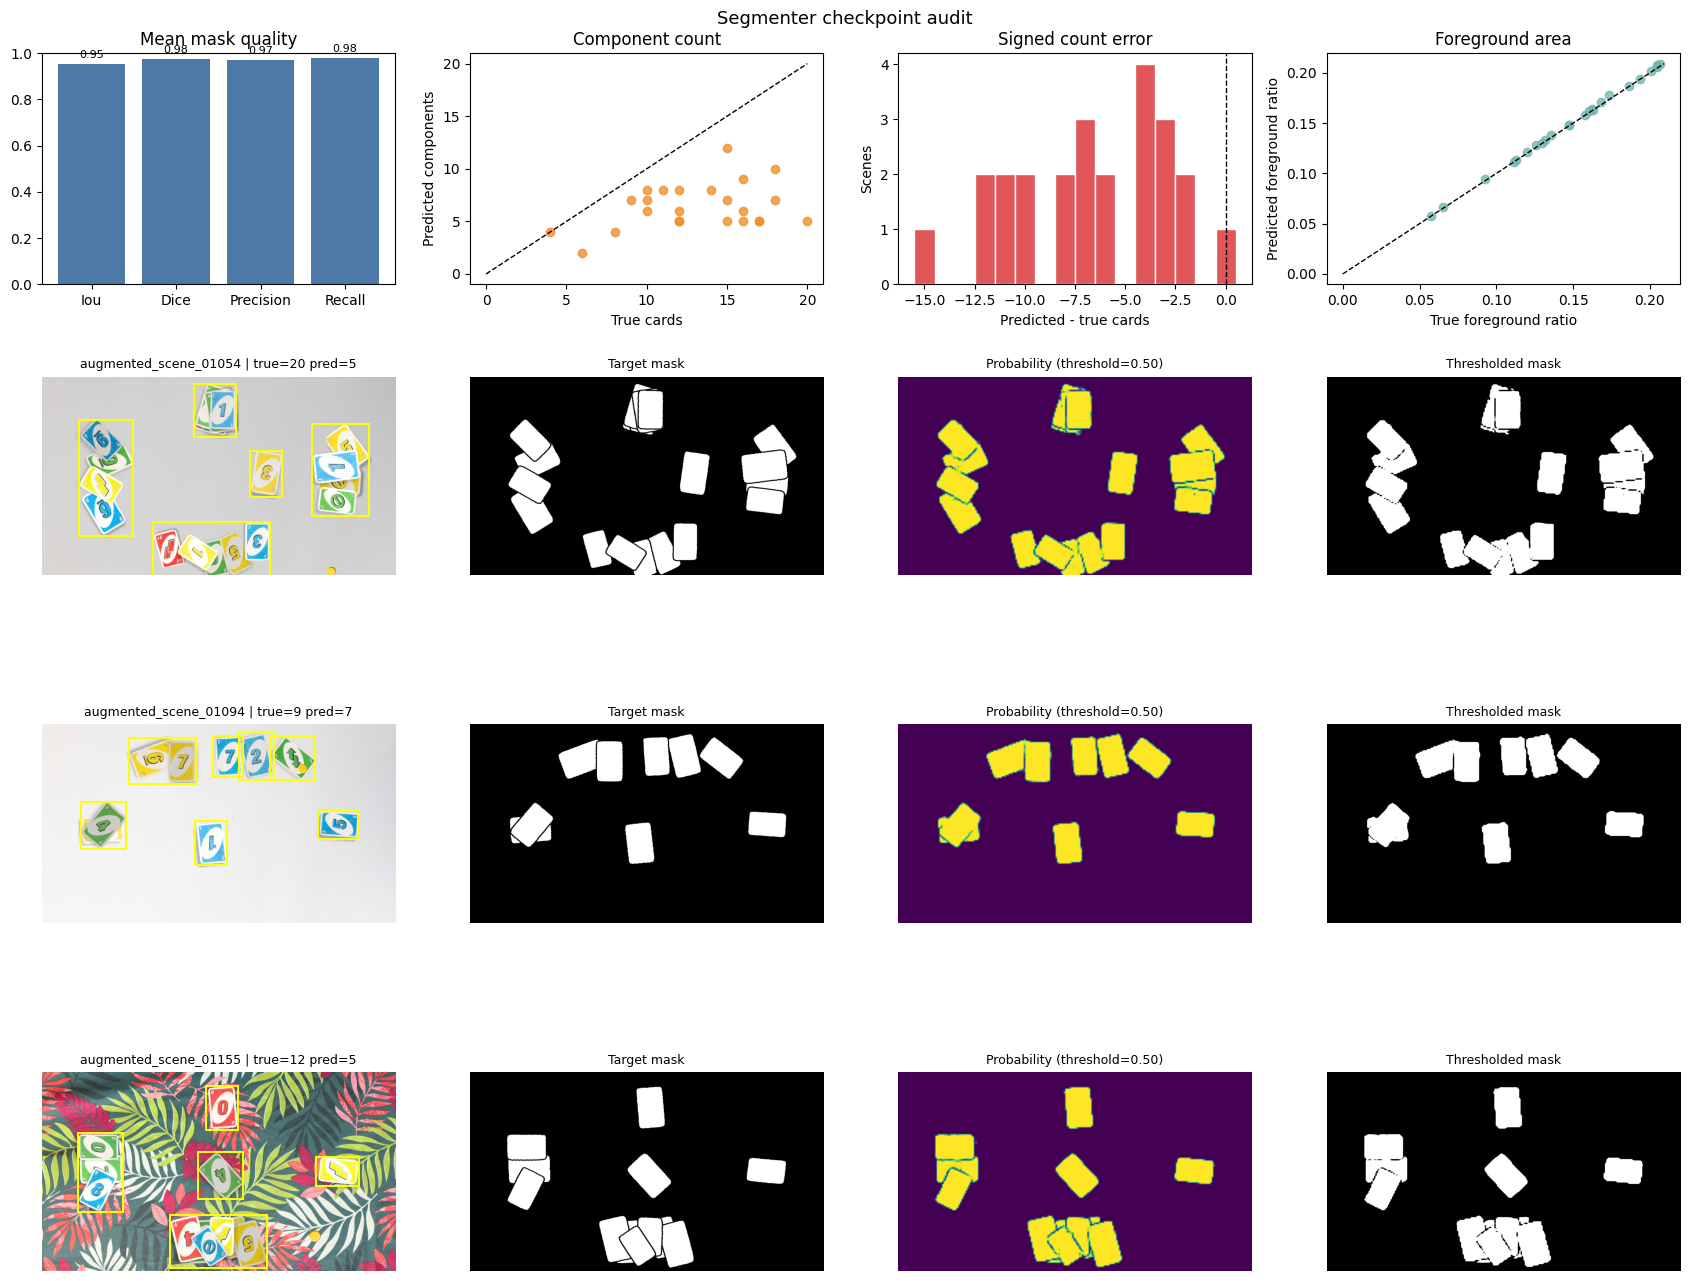

In [ ]:
RUN_SEGMENTER_TRAINING = True

segmenter_config = SegmenterPipelineConfig()

if RUN_SEGMENTER_TRAINING:
    segmenter_state = run_full_segmenter_training(segmenter_config, project_root=REPO_ROOT, models_dir=MODELS_DIR)
    try:
        plot_training_curves(segmenter_state)
    finally:
        release_segmenter_training_resources(segmenter_state)
elif GENERATED_SCENE_LABELS.exists() and any(GENERATED_SCENE_IMAGES.glob("*.jpg")) and any(GENERATED_SCENE_MASKS.glob("*.png")):
    segmenter_audit = evaluate_segmenter_checkpoint(engine, REPO_ROOT, sample_count=24, seed=42)
    print_segmenter_summary(segmenter_audit)
    plot_segmenter_audit(segmenter_audit, max_examples=3)
else:
    print("Generate augmented scenes first, then set RUN_SEGMENTER_TRAINING=True to train the U-Net.")

### 4.1 End-to-end stage preview

The next figure follows one labelled training image through the same segmentation, instance extraction, classification, and region-assignment path used by `main.py`.

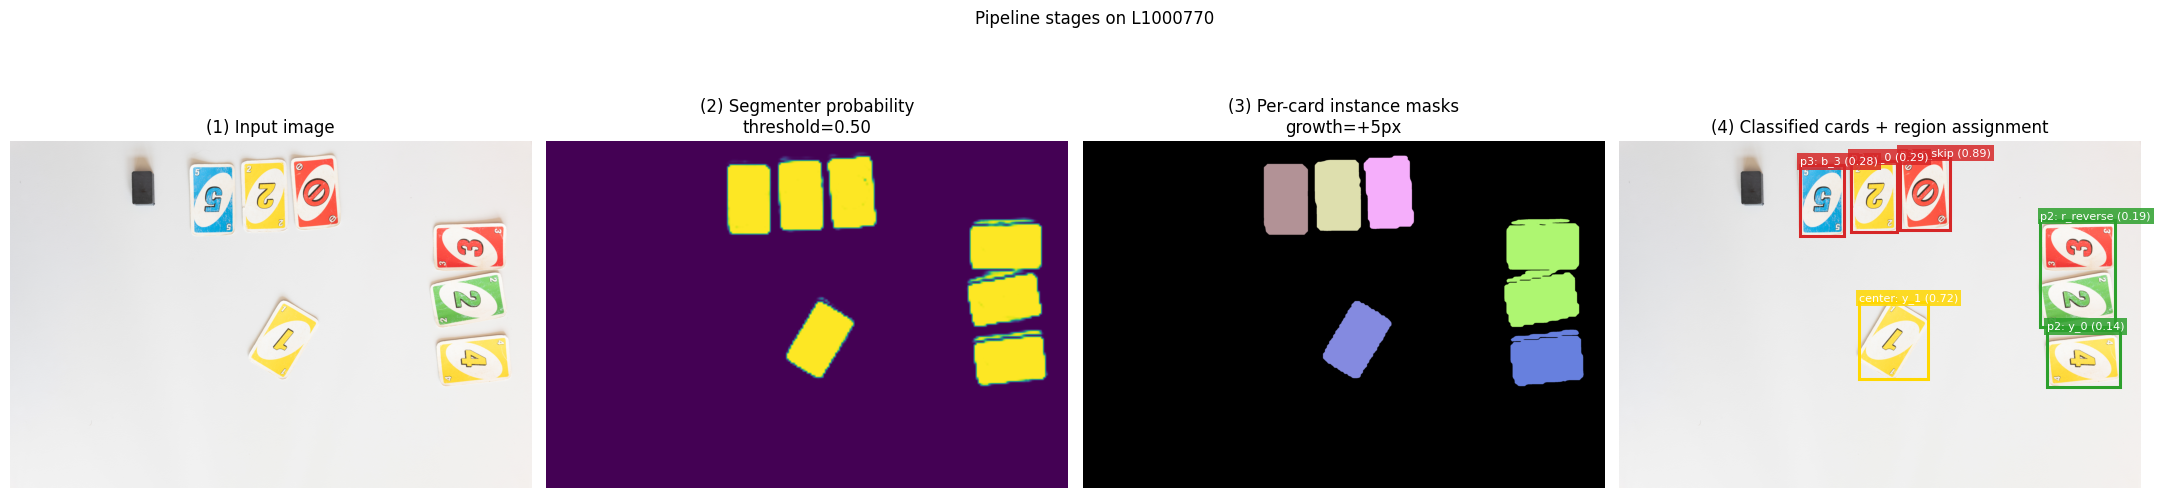

In [5]:
# Pick a representative training image (replace the id with anything visual).
demo_id = "L1000770"
demo_path = TRAIN_DIR / f"{demo_id}.jpg"
demo_state = predict_from_path(engine, demo_path)
demo_img = cv2.imread(str(demo_path), cv2.IMREAD_COLOR)

plot_pipeline_stages(engine, demo_img, demo_state.cards, title=f"Pipeline stages on {demo_id}")

## 5. Card Classifier Training and Diagnostics

The classifier uses a compact randomly initialized residual network with a 4-channel input: normalized RGB plus the binary card mask. Its training curriculum has two stages: augmented single-card crops, then card crops taken from synthetic scenes using the generated scene masks.

In [ ]:
RUN_CLASSIFIER_TRAINING = True

classifier_config = TrainPipelineConfig()

if RUN_CLASSIFIER_TRAINING:
    classifier_state = run_full_classifier_training(classifier_config, project_root=REPO_ROOT, models_dir=MODELS_DIR)
    plot_stage_preview(classifier_state, samples_per_stage=2, seed=42)
    plot_classifier_training_curves(classifier_state)
elif GENERATED_AUGMENTED_CARDS.exists():
    classifier_summary = summarize_classifier_training(MODELS_DIR, REPO_ROOT)
    print_classifier_summary(classifier_summary)
    print("Set RUN_CLASSIFIER_TRAINING=True to rerun the two-stage classifier curriculum and rewrite the classifier bundle.")
else:
    print("Generate augmented cards and scenes first, then set RUN_CLASSIFIER_TRAINING=True to train the classifier.")

Classifier: resnet18_small (rgb_plus_mask_channel), 54 classes, 9,853,134 params.
Checkpoint: val_acc=0.373, selection=0.380, best=stage2_scene_manual_masks/epoch 2, val_samples=32,344.
Set RUN_CLASSIFIER_TRAINING=True to rerun the two-stage classifier curriculum and rewrite the classifier bundle.


## 6. Region Assignment Geometry

Per R6, player positions are fixed: p1=bottom, p2=right, p3=top, p4=left. We map each card-box centroid to the nearest player edge, with a central rectangle reserved for the table card. This step is deterministic and does not use test-set tuning.

The diagram below makes the partition explicit.

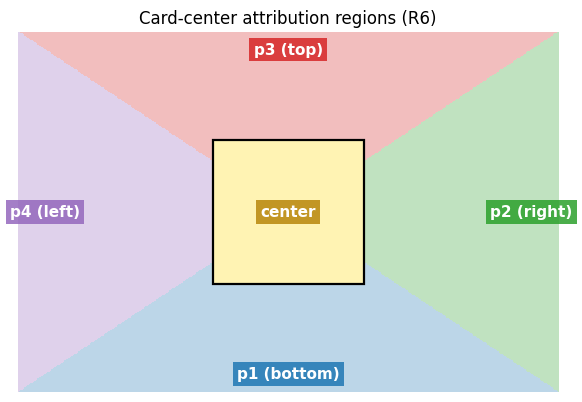

In [7]:
plot_region_layout()

## 7. Active Player Detection

The active player is recovered from the visible turn token before assembling the final row. Plain white-background scenes use the dark rectangular token detector, while textured-background scenes use the yellow round token detector. After the token center is found, the same fixed p1/p2/p3/p4 table layout maps it to a player label.

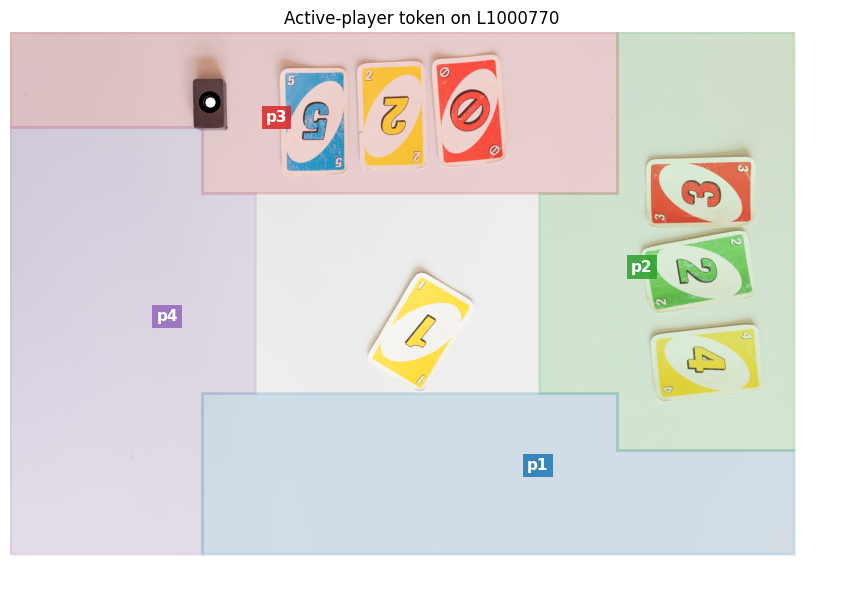

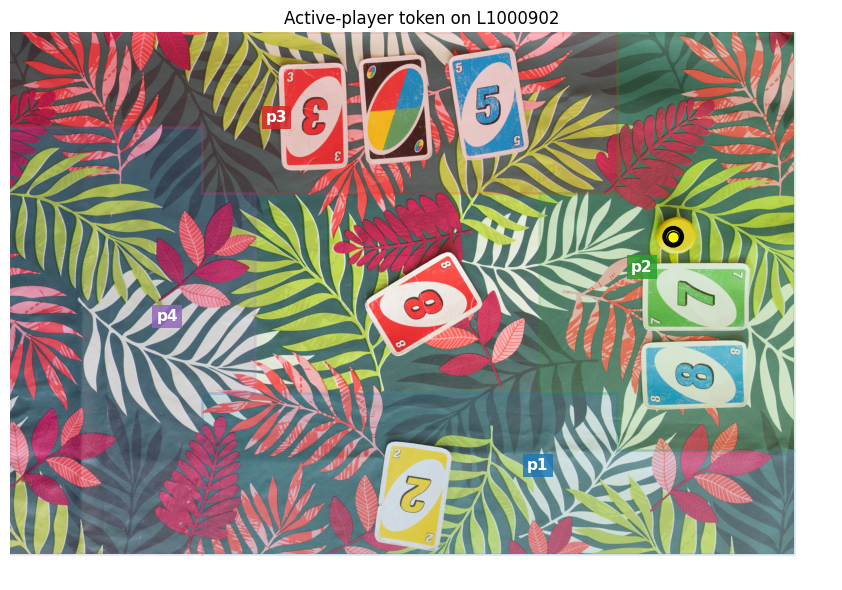

Active-player detector: accuracy=0.988, unknown=1, by token/background: dark rectangle=1.000 (42), yellow disk=0.974 (39).


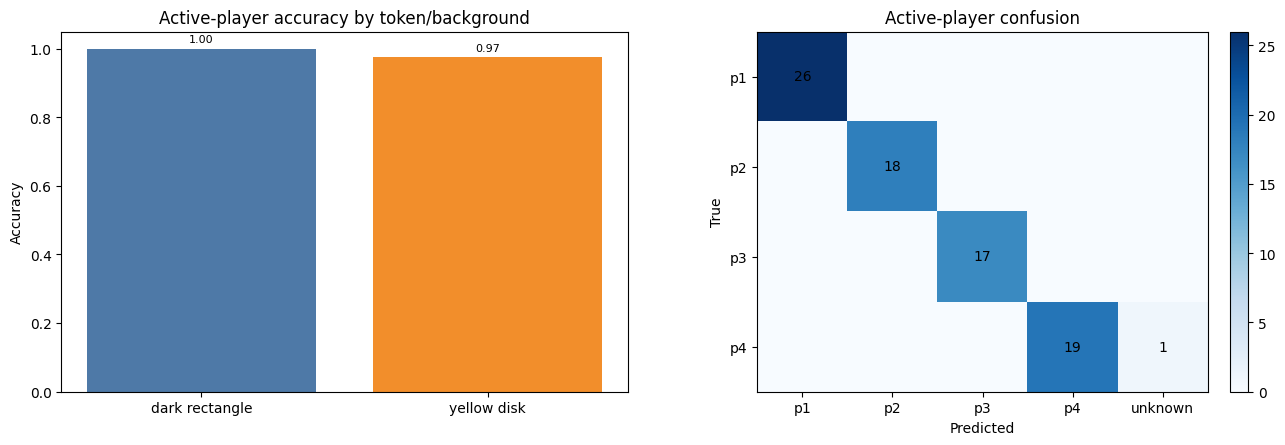

In [8]:
active_examples = ["L1000770", "L1000902"]
active_labels = pd.read_csv(TRAIN_CSV).set_index("image_id")

for active_demo_id in active_examples:
    active_demo_path = TRAIN_DIR / f"{active_demo_id}.jpg"
    active_demo_img = cv2.imread(str(active_demo_path), cv2.IMREAD_COLOR)
    expected_player = active_labels.loc[active_demo_id, "active_player"]
    plot_active_player_detection(
        active_demo_img,
        expected_player=expected_player,
        title=f"Active-player token on {active_demo_id}",
    )

active_summary = summarize_active_player_detection(TRAIN_CSV, TRAIN_DIR)
print_active_player_summary(active_summary)
plot_active_player_summary(active_summary)

## 8. Quantitative Evaluation

We score the structured game state locally with center-card accuracy, active-player accuracy, and bag F1 for each player hand. This is close to the competition target: it rewards recovering the active turn marker and the right multiset of cards while ignoring hand order.

### 8.1 Held-out benchmark on labelled training images

We use `run_labeled_benchmark` from `src.report_viz`, which evaluates the full inference pipeline on the official `train.csv` rows and plots the report figures.

Benchmark: 60 labelled images, segmenter threshold=0.50.
Benchmark summary: center=0.367, active=1.000, player_macro=0.490, overall=0.555, strict=0.544, count_MAE=1.98, cards pred/true=377/460.
Weakest labelled images: L1000981=0.17, L1000850=0.25, L1000906=0.25, L1000853=0.28.


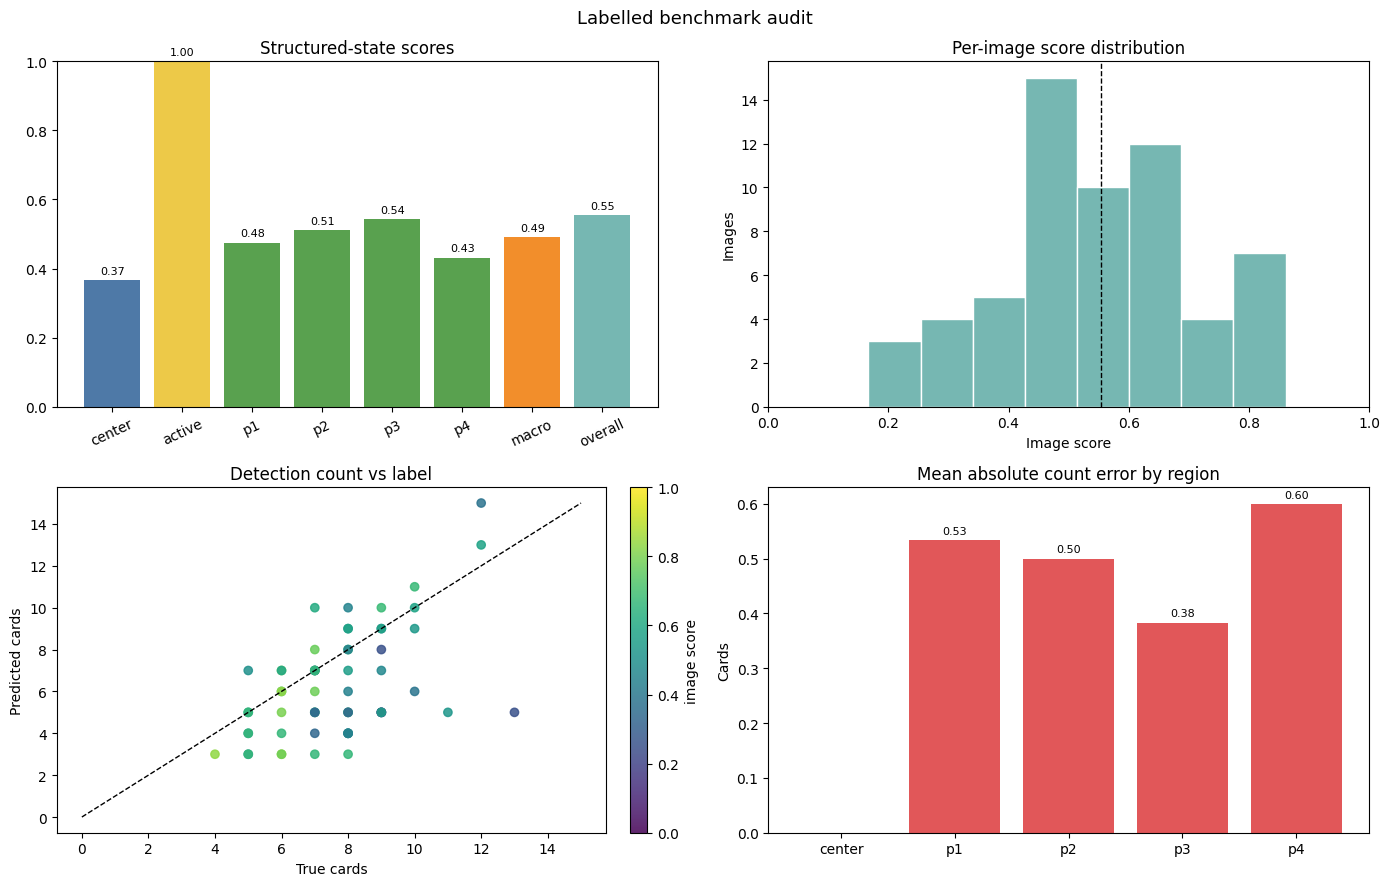

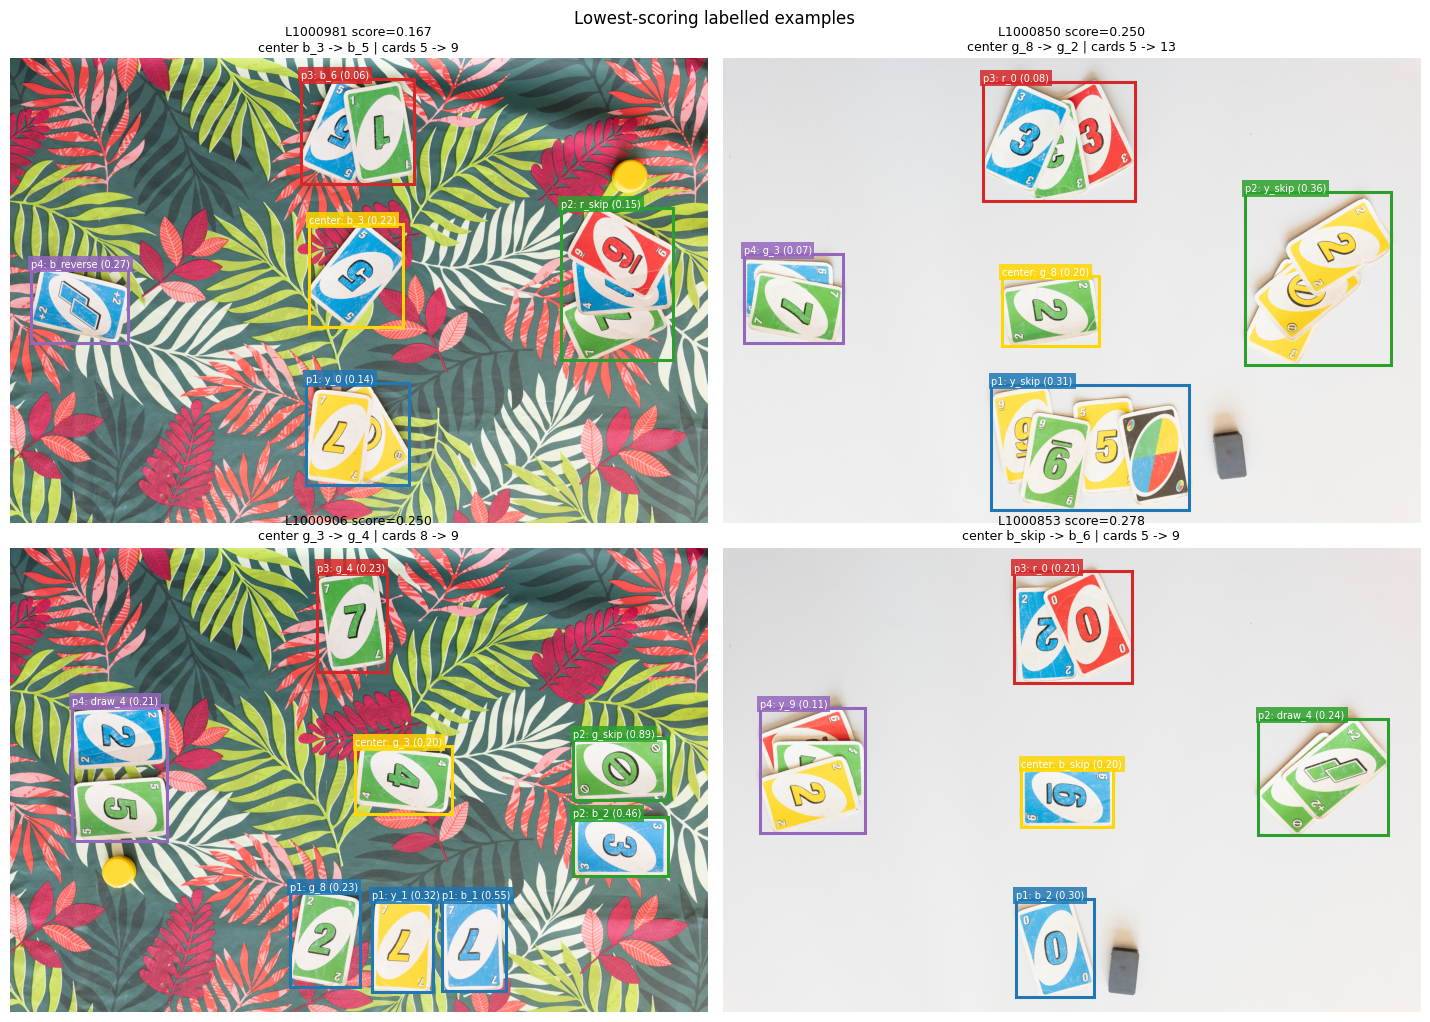

In [9]:
# Use eval_max_images=None for the full labelled-train reproduction.
benchmark = run_labeled_benchmark(
    engine,
    TRAIN_CSV,
    TRAIN_DIR,
    BenchmarkConfig(
        eval_max_images=60,
        eval_random_subset=True,
        eval_seed=42,
        worst_k=4,
        top_k=4,
    ),
)

The benchmark dashboard separates the main error sources: structured-state scores show whether center-card or hand recovery dominates, the score histogram shows consistency across labelled scenes, and the count panels reveal whether errors come from missing/extra detections or from region assignment. The gallery focuses on the lowest-scoring labelled examples because they are the most useful cases for explaining remaining failure modes.

## 9. Inference-Only Test Set Audit

We run the final pipeline on every test image only for inference and submission generation. The dashboard below is a sanity check of the predictions before writing the CSV: confidence, total detections, region counts, and the most frequent predicted card classes.

test inference:   0%|          | 0/159 [00:00<?, ?it/s]

Prediction audit: 159 images, 899 cards, mean cards/image=5.65, mean confidence=0.368.


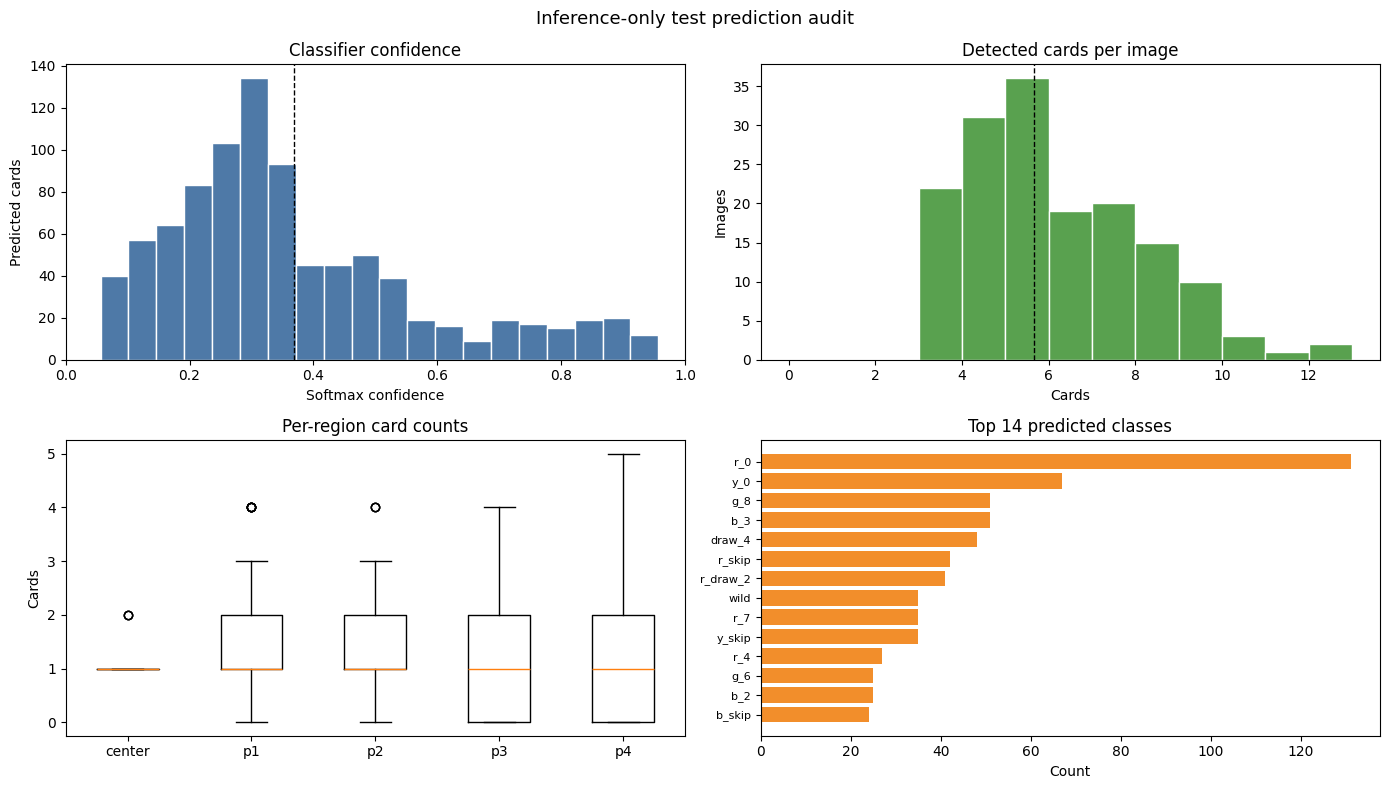

In [10]:
test_paths = sorted(TEST_DIR.glob("*.jpg"))
test_states = [predict_from_path(engine, path) for path in tqdm(test_paths, desc="test inference")]

test_summary = summarize_prediction_set(test_states)
print_prediction_set_summary(test_summary)
plot_prediction_set_diagnostics(test_summary, top_n=14)

## 10. Reproducing the Kaggle Submission

The submission CSV uploaded to Kaggle is produced by:

```bash
python main.py
```

The cell below writes the same schema from the already-computed test predictions so the notebook contains a self-contained reproduction check.

In [11]:
submission_path = write_submission(test_states, REPO_ROOT / "submission.csv", validate=True)
print(f"Wrote {submission_path.relative_to(REPO_ROOT)} with {len(test_states)} rows.")
pd.read_csv(submission_path).head()

Wrote submission.csv with 159 rows.


,image_id,center_card,active_player,player_1_cards,player_2_cards,player_3_cards,player_4_cards
0,L1000793,g_8,p2,EMPTY,r_0;r_reverse,r_0;b_skip;y_0,y_0;r_0;g_6
1,L1000794,y_4,p1,r_skip;y_9,EMPTY,g_7;b_6;r_0,EMPTY
2,L1000795,y_0,p1,g_4;wild;r_skip,EMPTY,EMPTY,b_7;r_0;draw_4;y_0;r_7
3,L1000796,b_3,p1,r_skip;g_6,wild;g_6,y_skip;b_4,draw_4
4,L1000797,y_0,p2,EMPTY,r_1;y_0,EMPTY,wild


## 11. Limitations and Future Work

The submitted pipeline now predicts the active-player token deterministically, but the detector can still fail if the marker is heavily occluded, clipped, or confused with similarly colored objects. The detector/classifier stack can also fail when segmentation merges overlapping cards or misses card corners. The most direct next improvements are an instance-aware segmentation head, active-token fallback candidates for difficult images, and confidence-aware rejection for low-quality card crops.